# Tracking Data Analysis
Reload and analyze time_tracking data from saved CSVs

In [3]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

from slab_qick_calib.calib.time_tracking import load_tracking
from slab_qick_calib.analysis import collections, allan, qubit_params
from slab_qick_calib.helpers import config
from slab_qick_calib.helpers import handy
%matplotlib inline
handy.config_figs()


<module 'slab_qick_calib.experiments' from 'C:\\_Lib\\python\\qq\\slab_qick_calib\\experiments\\__init__.py'>
C:\_Lib\python\qq\slab_qick_calib\experiments
imported slab_qick_calib.experiments.general.qick_experiment
imported slab_qick_calib.experiments.general.qick_experiment_2q
imported slab_qick_calib.experiments.general.qick_program
C:\_Lib\python\qq\slab_qick_calib\experiments\flux
imported slab_qick_calib.experiments.flux.pulse_probe_spectroscopy_flux
imported slab_qick_calib.experiments.flux.rabi_flux
imported slab_qick_calib.experiments.flux.single_shot_flux
imported slab_qick_calib.experiments.flux.t1_cont_flux
imported slab_qick_calib.experiments.flux.t1_fastflux_loop
C:\_Lib\python\qq\slab_qick_calib\experiments\general
C:\_Lib\python\qq\slab_qick_calib\experiments\single_qubit
imported slab_qick_calib.experiments.single_qubit.active_reset
imported slab_qick_calib.experiments.single_qubit.power_calibration
imported slab_qick_calib.experiments.single_qubit.pulse_probe_spectro

## Configuration

In [4]:
cfg_file = 'sample_50_rfboard.yml'
expt_path = r'C:\_Data'
cfg_path = os.path.join(os.getcwd(), '..', 'configs', cfg_file)

csv_dir = os.path.join(expt_path, 'Tracking', 'csv')
qubit_list = [0]

## Load tracking data from CSVs

In [5]:
tt, csv_pth, tt_stats, tracking_id = load_tracking(csv_dir)

Loaded tracking_id='2026_03_19_22_13_18.0hrs', qubits=[0, 1, 2]
  CSV last updated: 2026-03-20 09:08:37 (10h 0m ago)


 c:\Users\circu\anaconda3\envs\qick_calib\Lib\site-packages\numpy\_core\_methods.py: 194

## Process data and add derived quantities

In [6]:
tt, tt_ave = collections.process_data(tt)
tt = collections.add_losses(tt)

 c:\Users\circu\anaconda3\envs\qick_calib\Lib\site-packages\numpy\lib\_nanfunctions_impl.py: 1899

In [9]:
tt_ave

{'t1_mn': array([0.37272051, 0.43081569, 1.55965173]),
 't1_std': array([0.04385771, 0.06373629, 0.51996338]),
 't1_off_mn': array([ 1.39501734, -2.03935689,  9.85005504]),
 't1_off_std': array([0.56114366, 0.47176729, 2.49886323]),
 't1_amp_mn': array([15.63225643, 18.25850293,  7.96629213]),
 't1_amp_std': array([1.01115145, 1.94097814, 1.22348103]),
 't2_off_mn': array([ 7.12561705, 12.72253726, 13.28705829]),
 't2_off_std': array([1.63067807, 1.427027  , 2.65024251]),
 't2_amp_mn': array([9.53711857, 5.19594357, 4.10058385]),
 't2_amp_std': array([2.55255806, 7.64522689, 1.84045628]),
 't2_mn': array([1.28949693, 0.31468996, 4.12956557]),
 't2_std': array([0.7860916 , 0.09041095, 1.2005801 ]),
 'f_ge_mn': array([5640.04025852, 4542.96239283, 3398.70806947]),
 'f_ge_std': array([0.4675792 , 0.6612508 , 0.42784605]),
 't2_err_mn': array([96323200.22243494,               inf, 31023745.68462921]),
 't2_err_std': array([3.18917662e+09,            nan, 9.80995593e+08]),
 'fge_err_mn': ar

## Allan variance analysis

 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16

Combined fit failed: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.


 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16RuntimeWarning: invalid value encountered in subtract
 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16

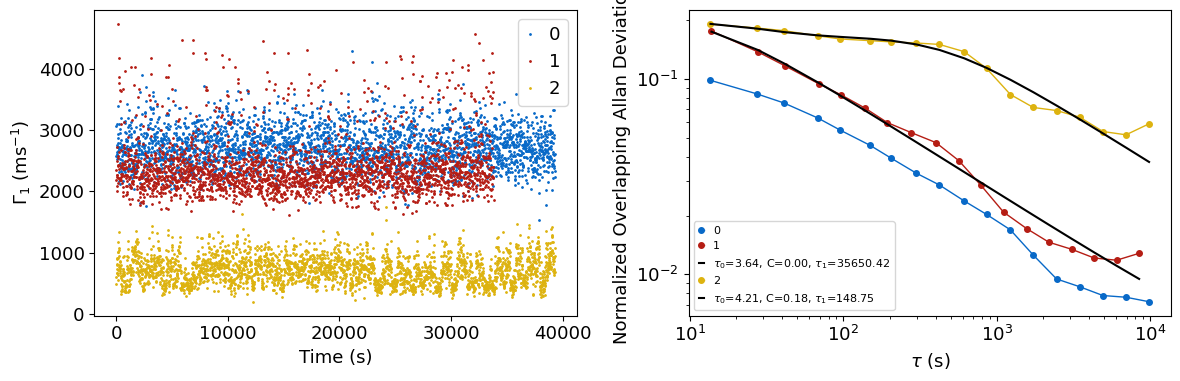

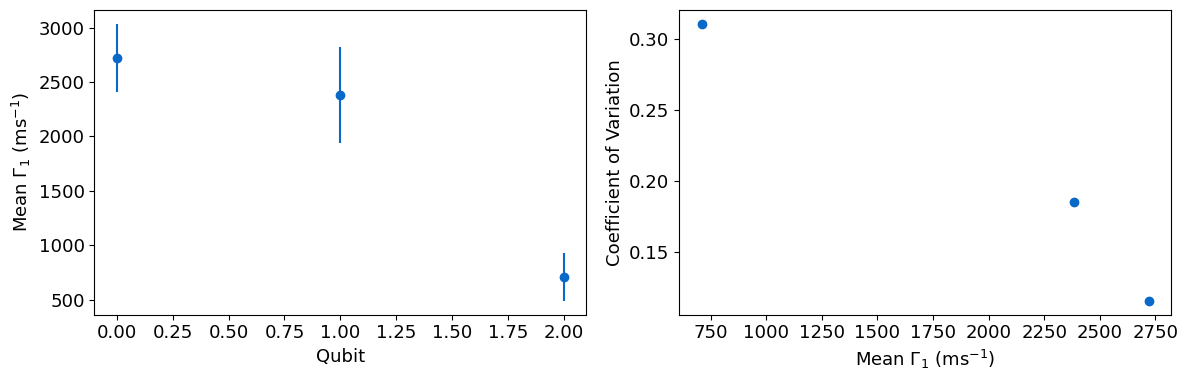

In [7]:
allan.perform_analysis(tt, param='Gamma1', save_path=csv_pth, tracking_id=tracking_id)

## Allan analysis (allantools)

Enhanced Allan deviation analysis using the `allantools` package.

### Deviation types

| Abbreviation | Name | Description |
|---|---|---|
| **ADEV** | Allan Deviation | Standard two-sample deviation. Most common stability measure. |
| **OADEV** | Overlapping Allan Deviation | Uses overlapping samples for better confidence at long tau. Same expectation as ADEV but lower variance. |
| **MDEV** | Modified Allan Deviation | Can distinguish white PM from flicker PM noise (ADEV cannot). |
| **HDEV** | Hadamard Deviation | Insensitive to linear frequency drift — useful when drift dominates. |
| **OHDEV** | Overlapping Hadamard Deviation | Overlapping version of HDEV. |
| **TDEV** | Time Deviation | Derived from MDEV; characterizes time stability rather than frequency stability. |
| **TOTDEV** | Total Deviation | Extends analysis to longer tau by reflecting data at boundaries. |

### Noise types (from log-log slope of ADEV vs tau)

| Abbreviation | Name | ADEV slope | Physical origin (qubit context) |
|---|---|---|---|
| **WPM** | White Phase Modulation | -1 | Measurement noise, digitization |
| **FPM** | Flicker Phase Modulation | -1 (same as WPM for ADEV) | Low-frequency measurement artifacts |
| **WFM** | White Frequency Modulation | -1/2 | Uncorrelated shot-to-shot fluctuations (e.g. photon shot noise, thermal noise) |
| **FFM** | Flicker Frequency Modulation | 0 (flat) | 1/f noise — TLS defects, charge noise, flux noise |
| **RWFM** | Random Walk Frequency Modulation | +1/2 | Diffusive drift — slow temperature or field drifts |

A slope that flattens or rises at long tau typically indicates correlated (1/f) or drifting noise, while a -1/2 slope indicates white (uncorrelated) fluctuations.


Gamma1
Qubit 0: lorentz_two fit failed: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.


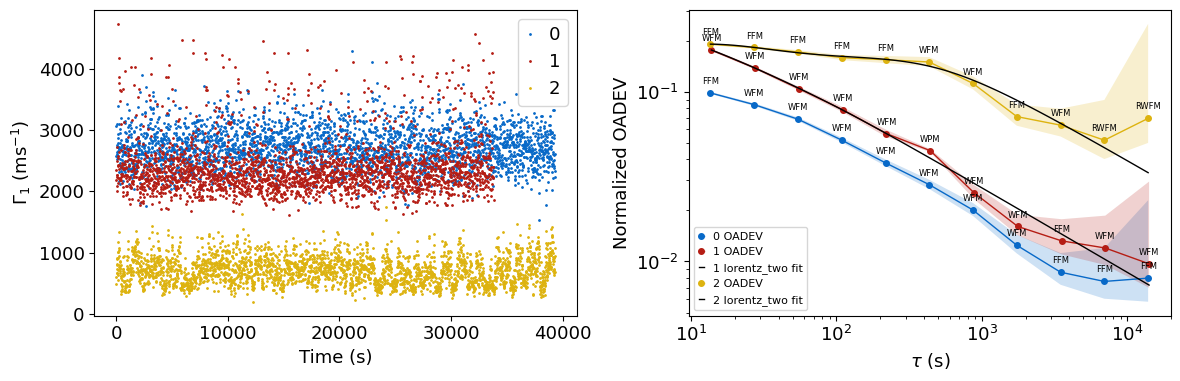

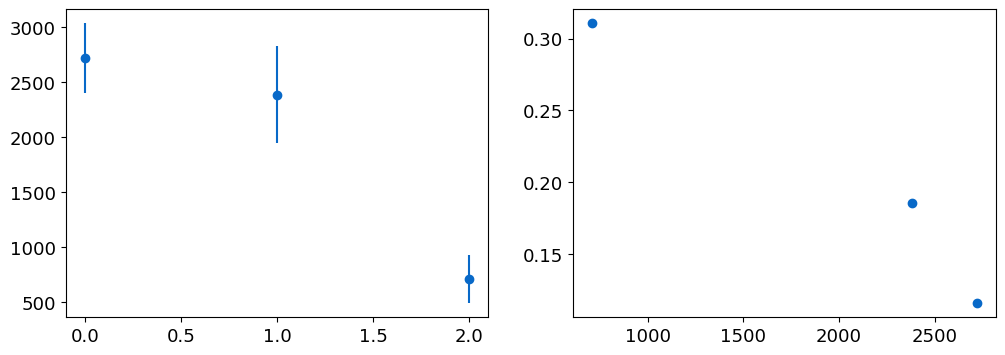


t1
Qubit 0: lorentz_two fit failed: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.


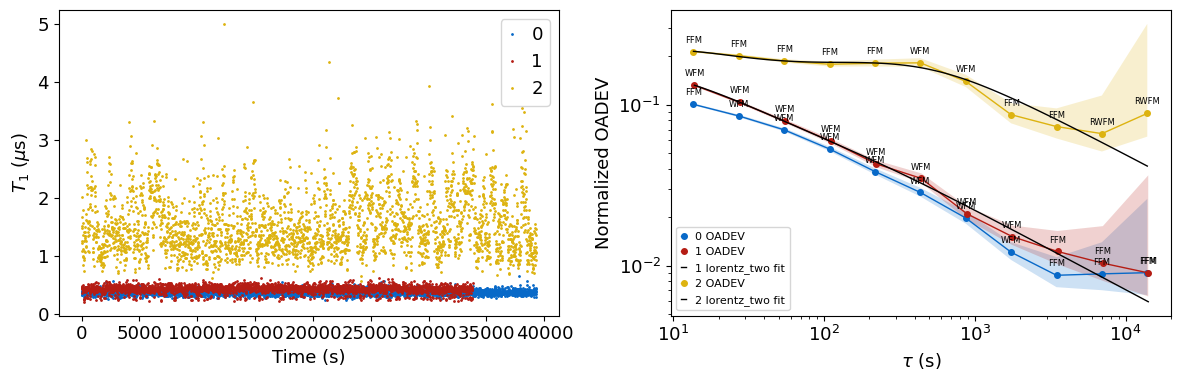

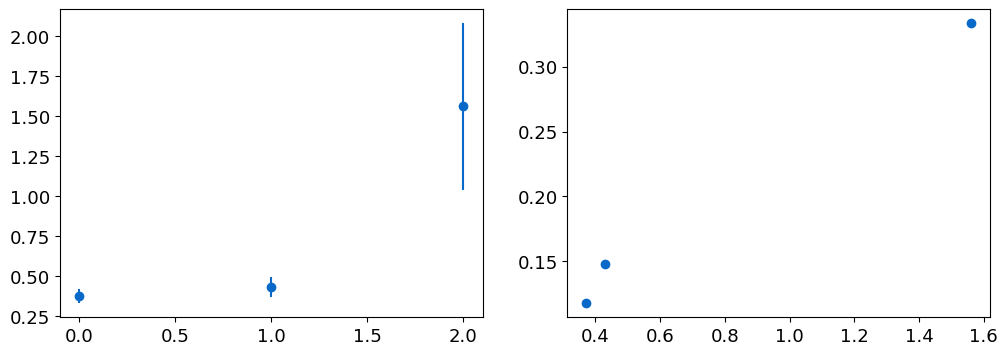


f_ge


IndexError: index 2449 is out of bounds for axis 0 with size 2449

In [8]:
from slab_qick_calib.analysis.allan_at import perform_analysis_at, plot_deviation_comparison

# Full analysis per parameter with OADEV + fit
for param in ['Gamma1', 't1', 'f_ge']:
    print(f"\n{'='*60}\n{param}\n{'='*60}")
    perform_analysis_at(
        tt, param=param,
        dev_types=('oadev',), taus='octave',
        fit_models=('lorentz_two',),
        show_ci=True, show_noise_id=True,
    )

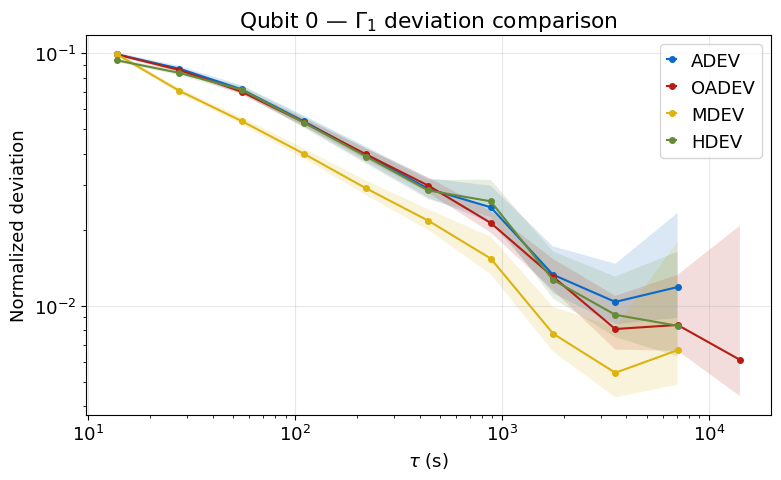

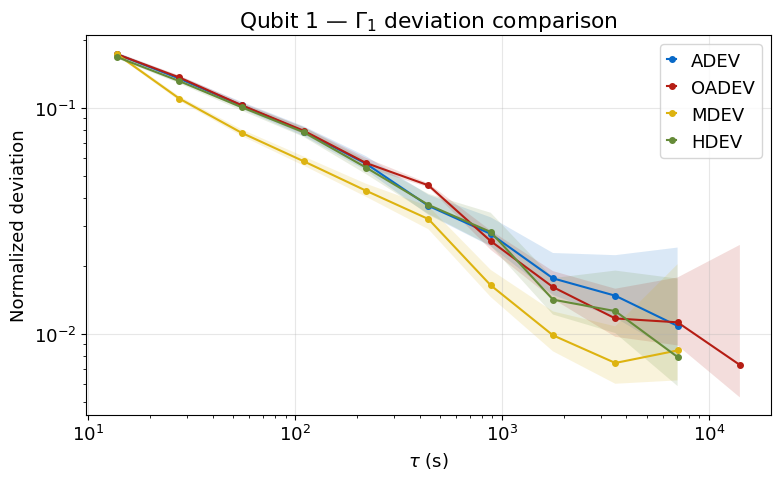

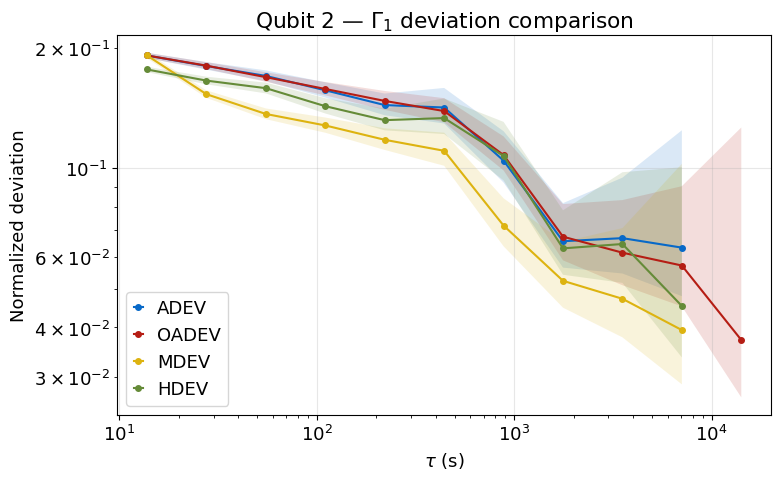

In [ ]:
# Compare deviation types (ADEV, OADEV, MDEV, HDEV) for Gamma1
for qi in range(len(tt)):
    data = np.array(tt[qi]['Gamma1'])
    times = np.array(tt[qi]['time'])
    rate = 1.0 / np.mean(np.diff(times))
    plot_deviation_comparison(
        data, rate=rate,
        dev_types=('adev', 'oadev', 'mdev', 'hdev'),
        taus='octave', show_ci=True,
        title=f'Qubit {qi} — $\\Gamma_1$ deviation comparison',
    )
    plt.show()

## Time series and histograms

Number of bad inds for t1 is 5
Number of bad inds for t2 is 80
Number of bad inds for tphi is 2028
Number of bad inds for f_ge is 21
Number of bad inds for t1 is 0
Number of bad inds for t2 is 169
Number of bad inds for tphi is 169
Number of bad inds for f_ge is 169
Number of bad inds for t1 is 76
Number of bad inds for t2 is 442
Number of bad inds for tphi is 2035
Number of bad inds for f_ge is 543


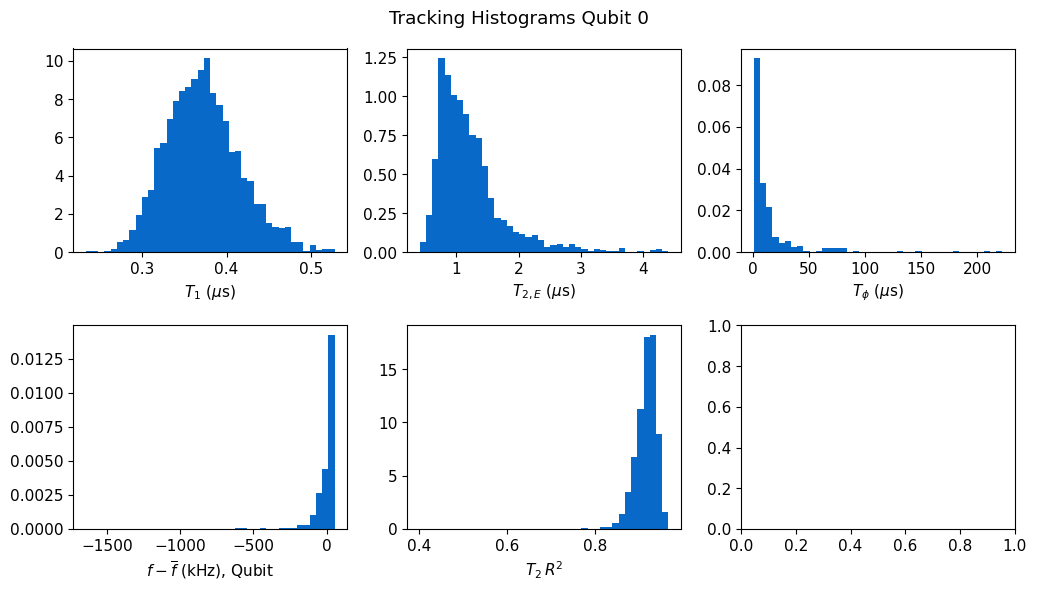

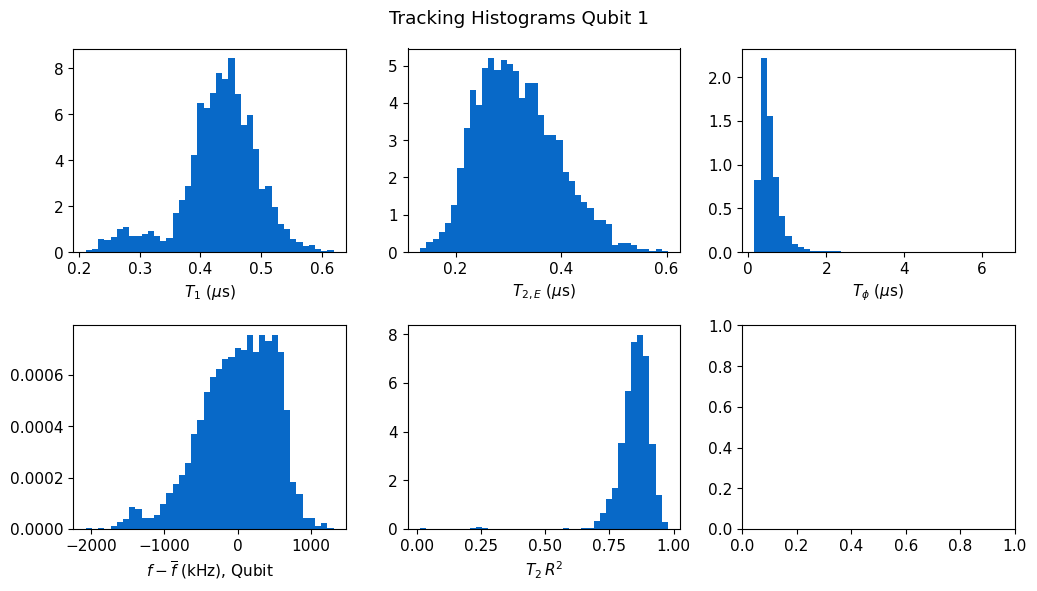

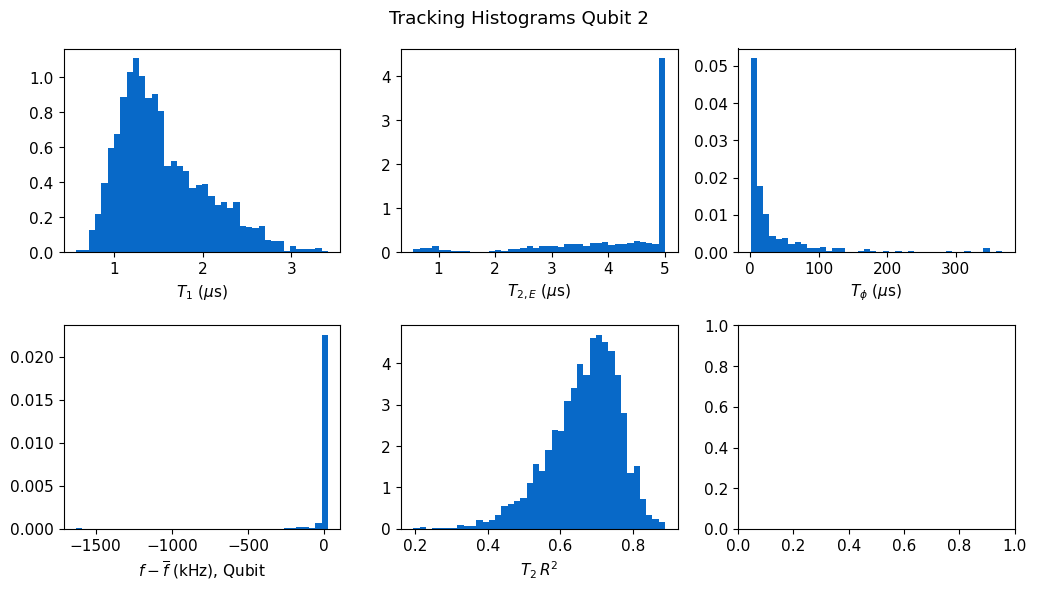

In [ ]:
collections.plot_all(tt, param_keys=['t1', 't2', 'tphi', 'f_ge', 't2_r2'], save_path=csv_pth, tracking_id=tracking_id)
plt.show()

Number of bad inds for Gamma1 is 2
Number of bad inds for Gamma2 is 21
Number of bad inds for Gammaphi is 2024
Number of bad inds for f_ge is 21
Number of bad inds for Gamma1 is 22
Number of bad inds for Gamma2 is 166
Number of bad inds for Gammaphi is 167
Number of bad inds for f_ge is 169
Number of bad inds for Gamma1 is 73
Number of bad inds for Gamma2 is 474
Number of bad inds for Gammaphi is 2031
Number of bad inds for f_ge is 543


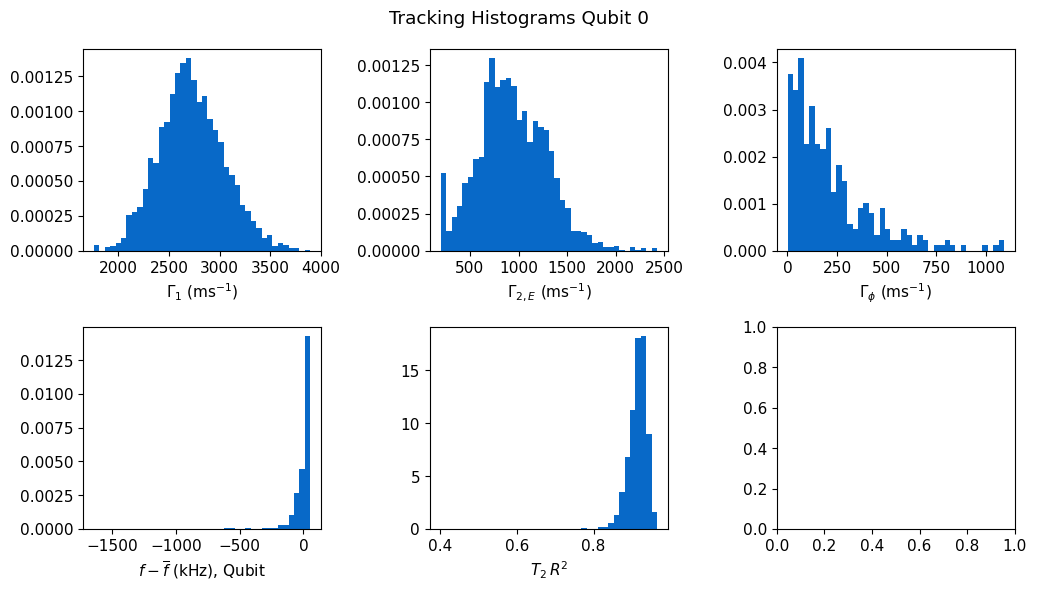

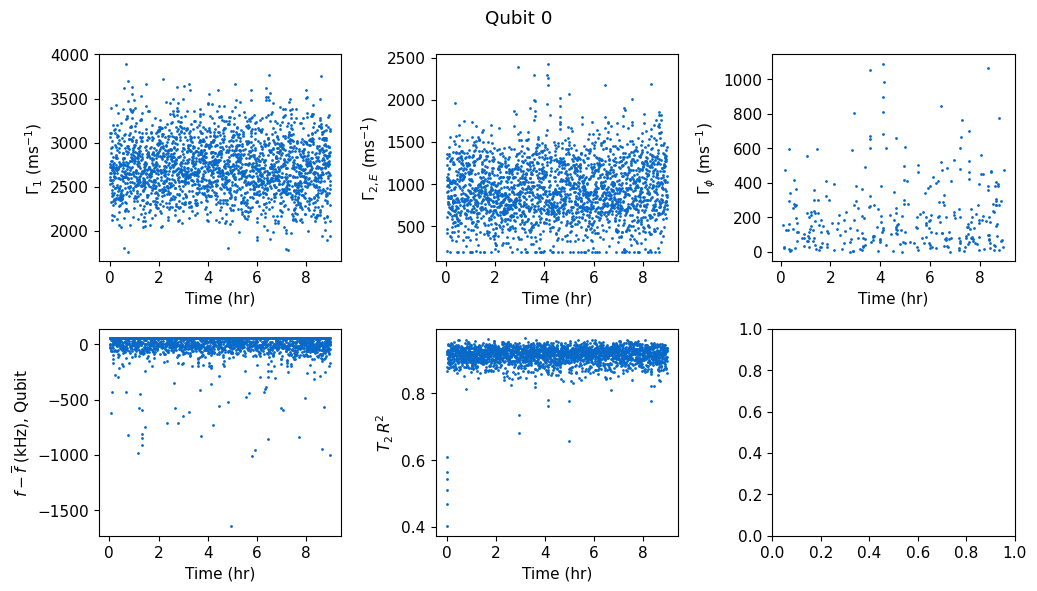

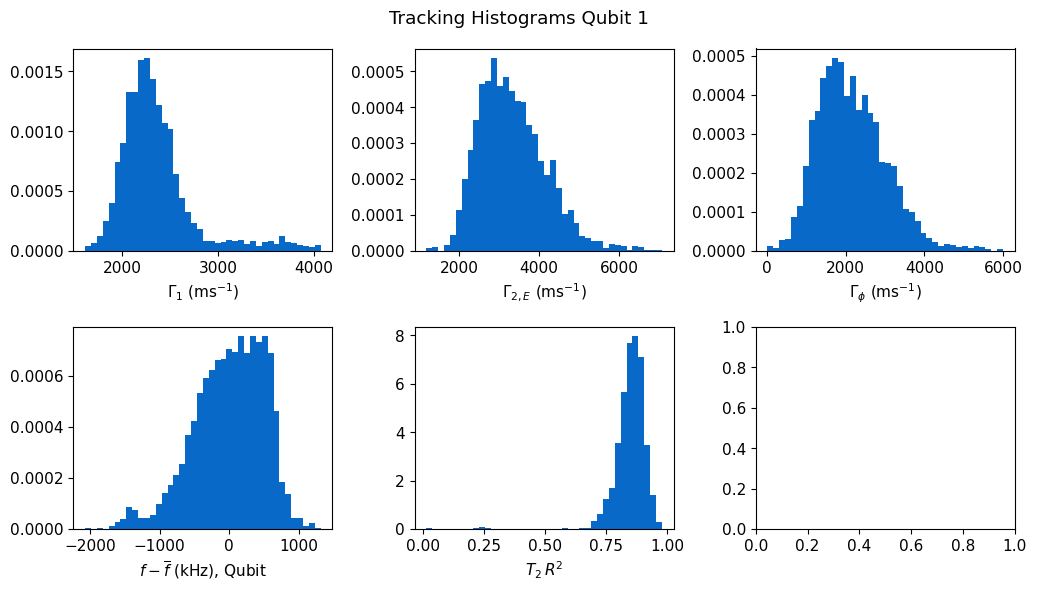

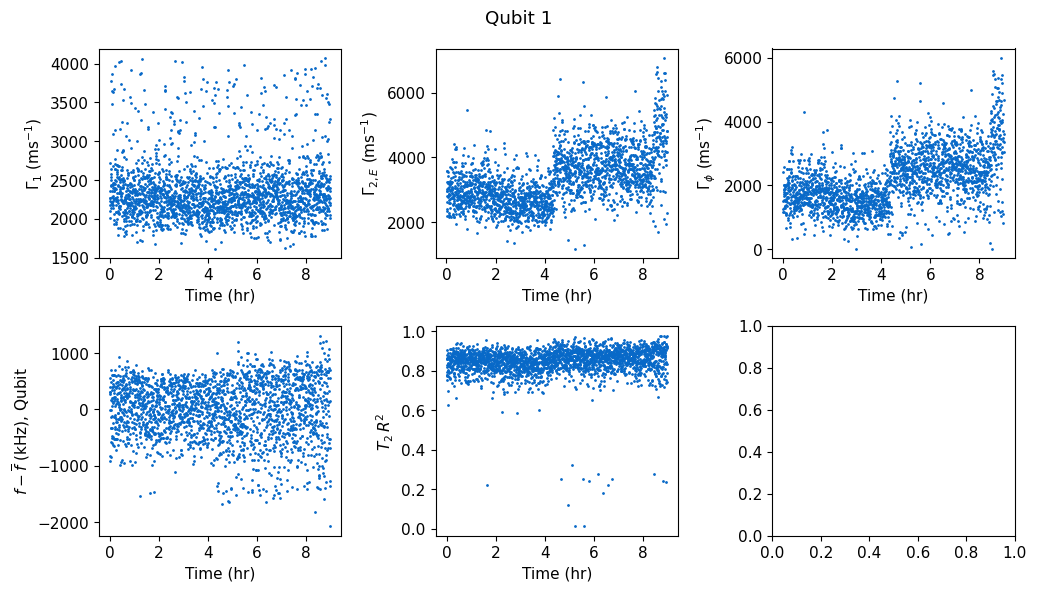

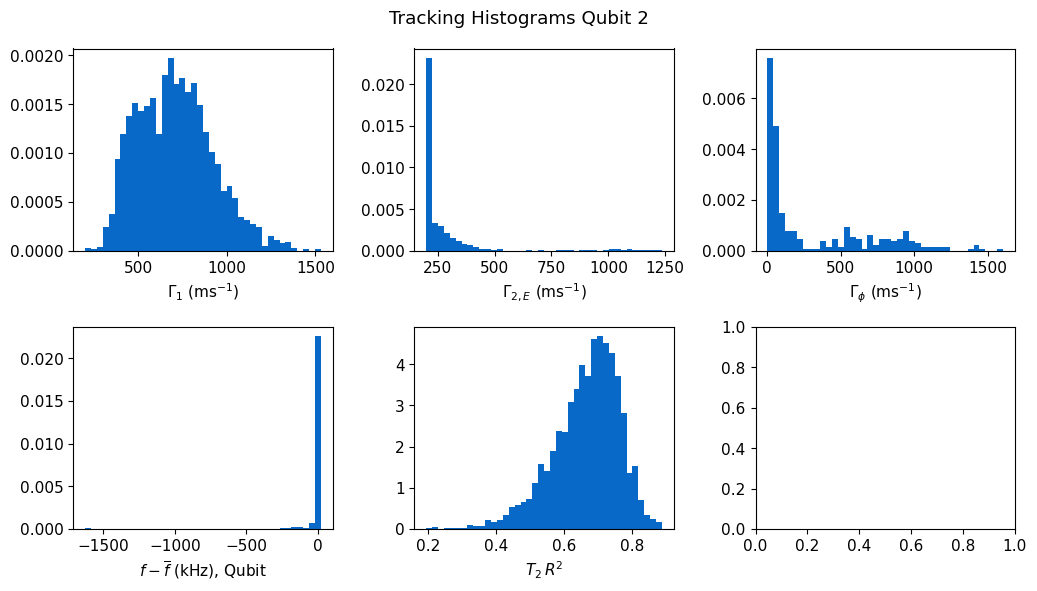

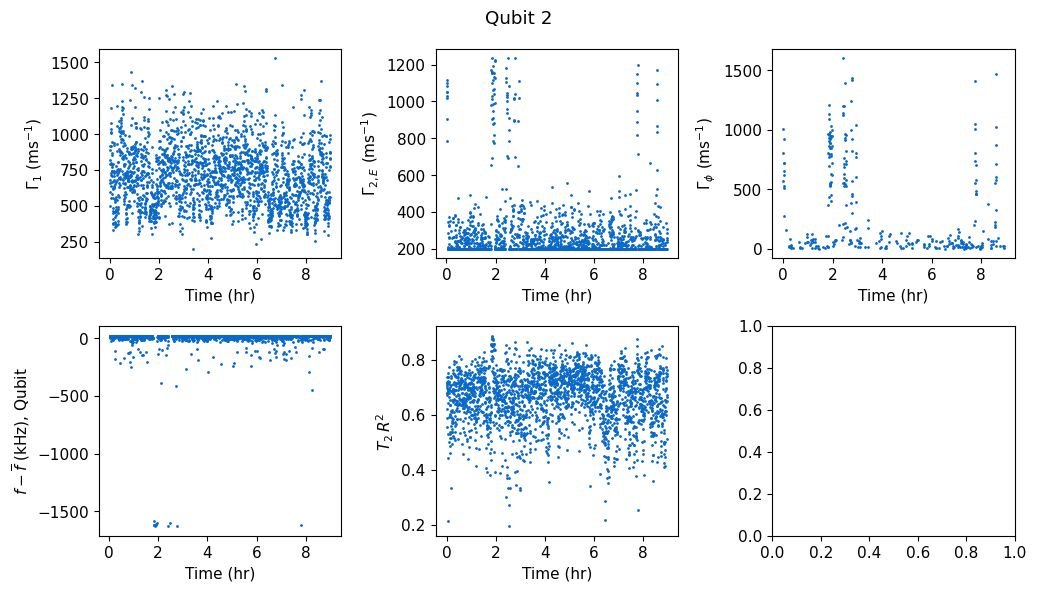

In [ ]:
collections.plot_all(tt, param_keys=['Gamma1', 'Gamma2', 'Gammaphi', 'f_ge','t2_r2'], plot_time=True, save_path=csv_pth, tracking_id=tracking_id)
plt.show()

## Violin plots

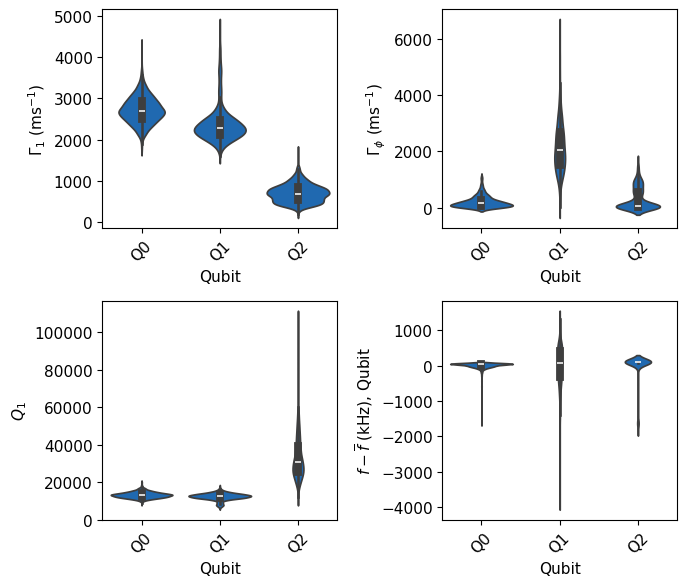

In [ ]:
collections.plot_violin(tt, param_keys=['Gamma1', 'Gammaphi', 'q', 'f_ge'], csv_path=csv_pth)
plt.show()

## Power Spectral Density Analysis

Median time between measurements: 13.7 s
Sampling frequency: 0.0733 Hz

Analyzing Gamma1...


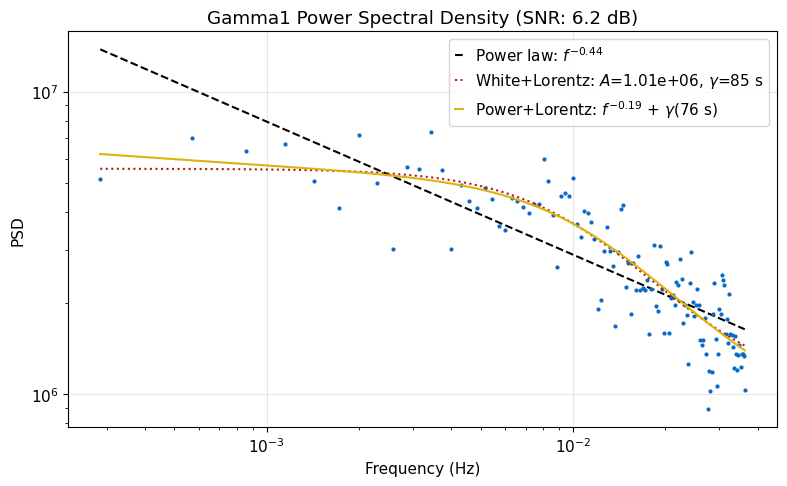

Peak frequency: 3.4340e-03 Hz (Period: 291.2 s)
Total power: 1.0394e+05
SNR: 6.2 dB

Analyzing Gammaphi...


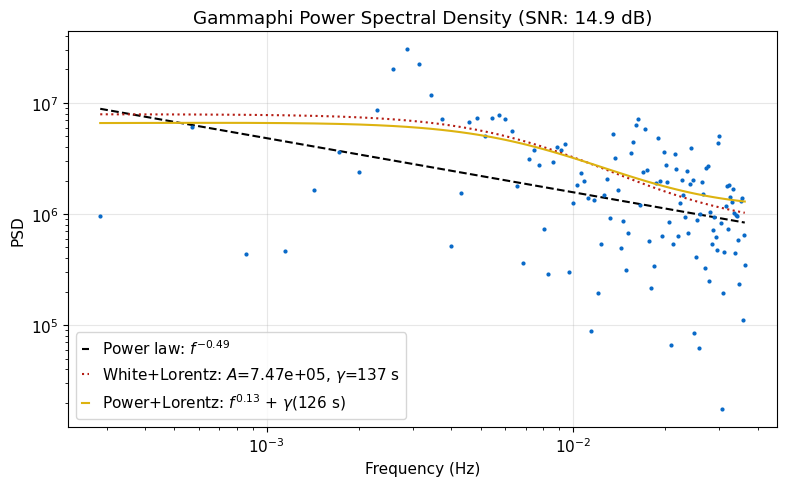

Peak frequency: 2.8617e-03 Hz (Period: 349.4 s)
Total power: 9.8930e+04
SNR: 14.9 dB

Analyzing f_ge...


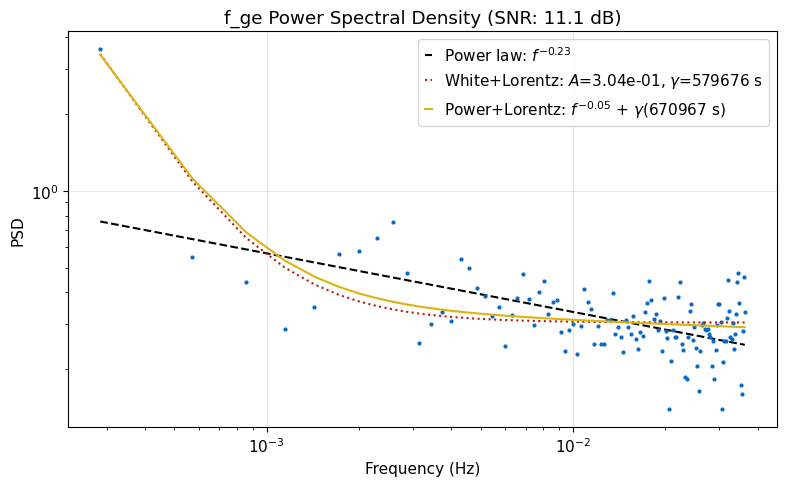

Peak frequency: 2.8617e-04 Hz (Period: 3494.4 s)
Total power: 1.3444e-02
SNR: 11.1 dB

Analyzing t1...


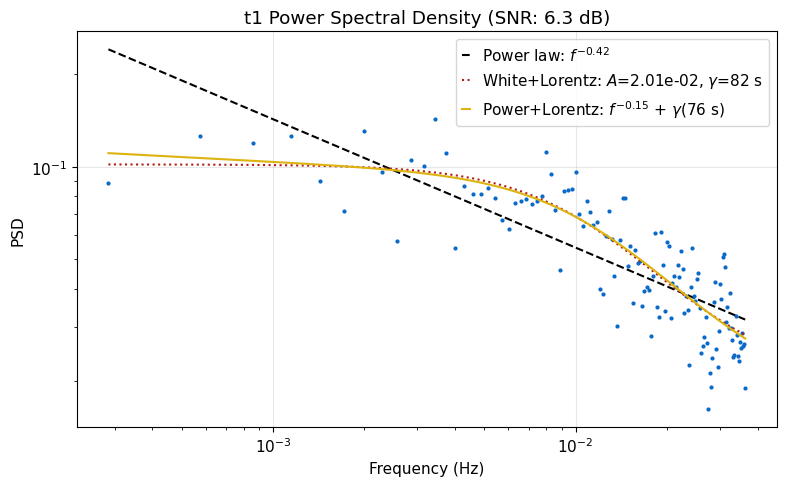

Peak frequency: 3.4340e-03 Hz (Period: 291.2 s)
Total power: 1.9622e-03
SNR: 6.3 dB


In [ ]:
from slab_qick_calib.analysis.time_series import analyze_qubit_psd

# Calculate sampling frequency from timestamps
timestamps = tt[0]['time']
dt = np.median(np.diff(timestamps))  # median time between measurements (in seconds)
fs = 1 / dt  # sampling frequency in Hz

print(f"Median time between measurements: {dt:.1f} s")
print(f"Sampling frequency: {fs:.4f} Hz")

# Analyze PSD for different parameters
params_to_analyze = ['Gamma1', 'Gammaphi', 'f_ge', 't1']

for param in params_to_analyze:
    if param in tt[0]:
        data = tt[0][param]
        print(f"\n{'='*60}")
        print(f"Analyzing {param}...")
        results = analyze_qubit_psd(
            data,
            fs=fs,
            parameter_name=param,
            qubit_id=0,
            plot=True,
            save_path=csv_pth,
            tracking_id=tracking_id,
        )
        if results:
            print(f"Peak frequency: {results['peak_freq']:.4e} Hz (Period: {1/results['peak_freq']:.1f} s)")
            print(f"Total power: {results['total_power']:.4e}")
            print(f"SNR: {results['snr_db']:.1f} dB")

## Parameter vs MXC temperature

In [ ]:
collections.plot_vs_temperature(tt, param_keys=['t1', 'tphi', 'f_ge', 'Gamma1'], save_path=csv_pth, tracking_id=tracking_id)

[]

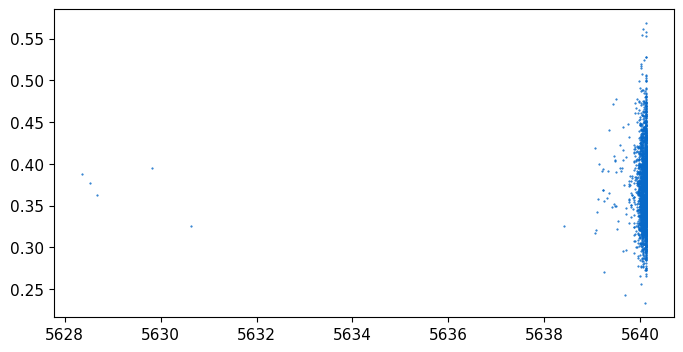

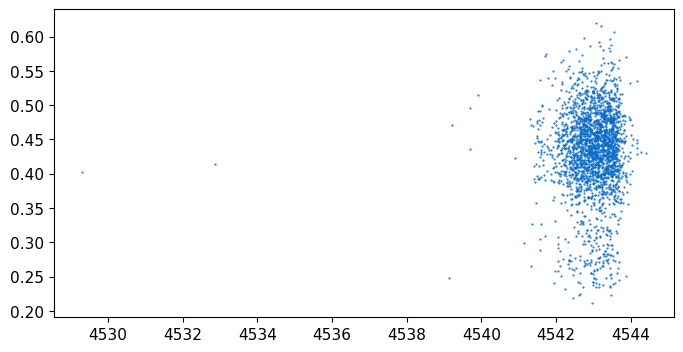

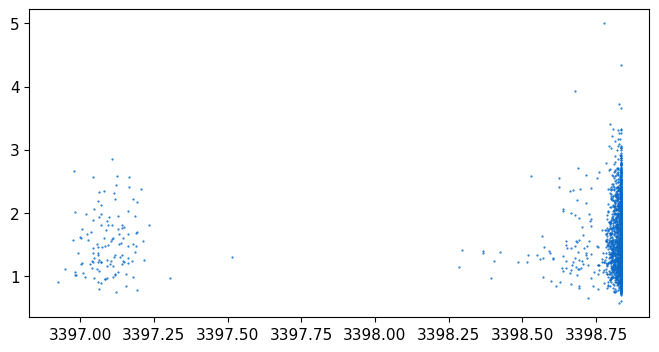

In [ ]:
for t in tt:
    plt.figure()
    plt.plot(t['f_ge'], t['t1'], '.')
    plt.show()

## Random scan overlays

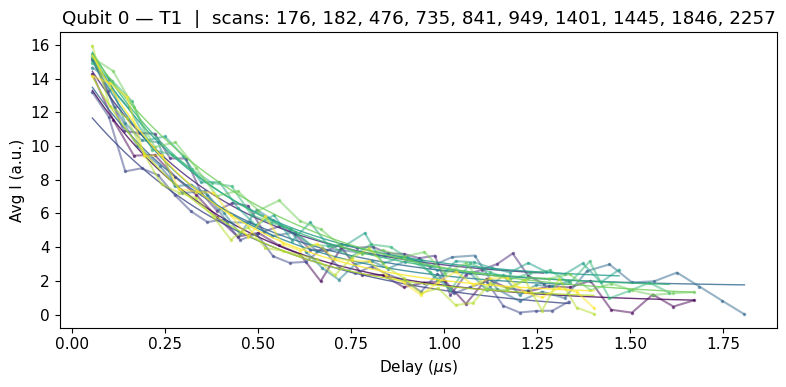

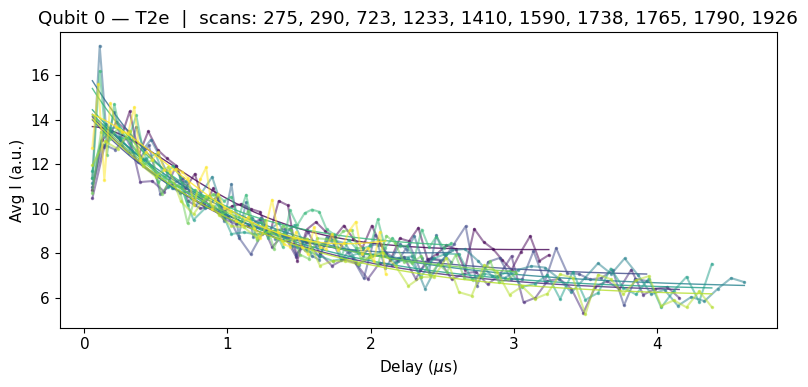

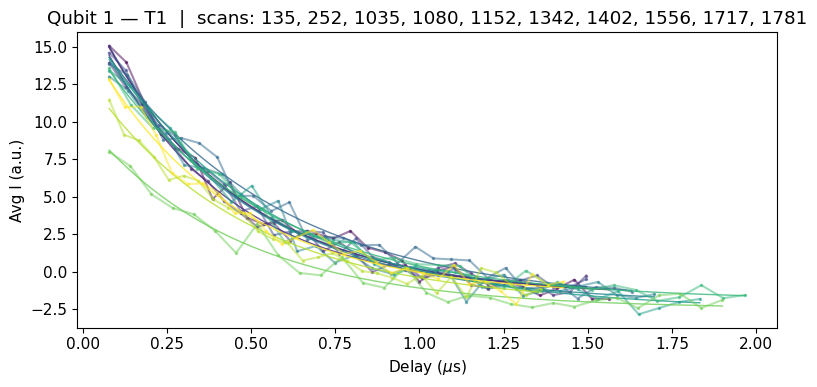

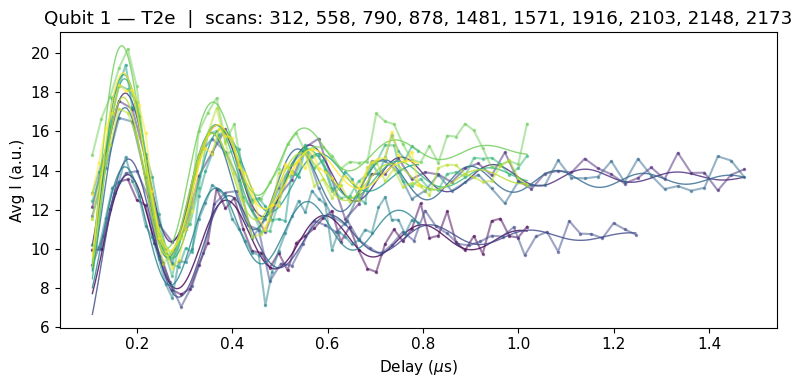

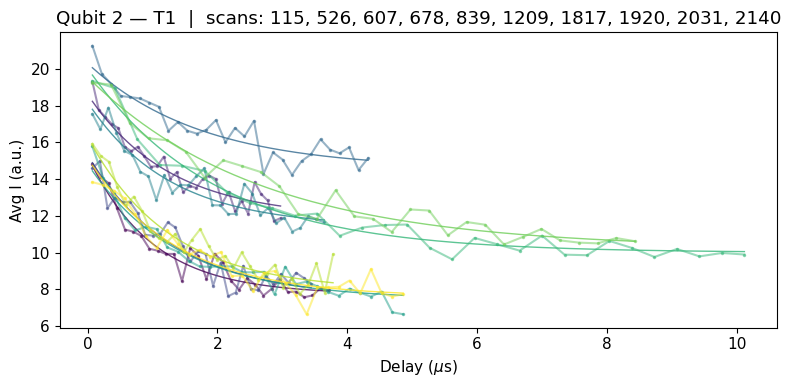

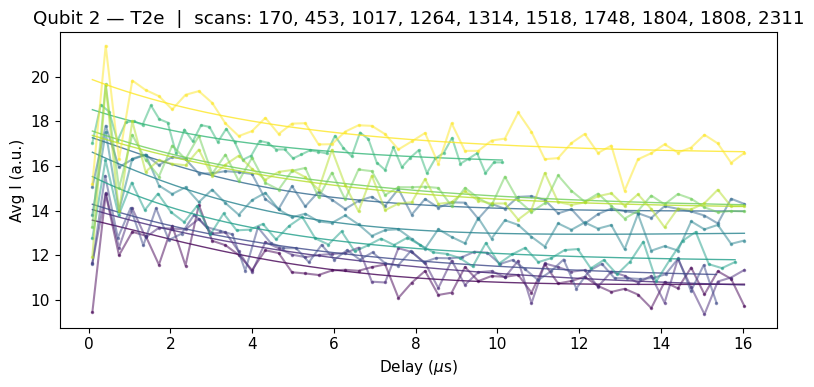

In [ ]:
import h5py
from pathlib import Path
from slab_qick_calib.analysis.fitting import expfunc, decaysin, decayslopesin

tracking_dir = Path(expt_path) / 'Tracking' / tracking_id
N_SCANS = 10

def load_scan(fpath):
    with h5py.File(fpath, 'r') as f:
        return {
            'xpts': f['xpts'][:],
            'avgi': f['avgi'][:],
            'fit': f['fit_avgi'][:],
        }

def t2_fit(x, fit):
    return decayslopesin(x, *fit) if len(fit) == 6 else decaysin(x, *fit)

qubits = [qi for qi, _ in enumerate(tt)]
colors = plt.cm.viridis(np.linspace(0, 1, N_SCANS))

for qi in qubits:
    for expt_type, label, fit_fn in [
        (f't1_qubit{qi}', 'T1', lambda x, fit: expfunc(x, *fit)),
        (f'T2e_qubit{qi}', 'T2e', t2_fit),
    ]:
        files = sorted(tracking_dir.glob(f'{expt_type}_*'))
        if not files:
            print(f'No {label} files found for qubit {qi}')
            continue

        chosen = np.random.choice(len(files), size=min(N_SCANS, len(files)), replace=False)
        chosen_files = [files[i] for i in sorted(chosen)]

        fig, ax = plt.subplots()
        scan_labels = []
        for color, fpath in zip(colors, chosen_files):
            scan_num = int(fpath.stem.split('_')[-1])
            scan_labels.append(str(scan_num))
            d = load_scan(fpath)
            ax.plot(d['xpts'], d['avgi'], '.-', color=color, alpha=0.5, markersize=3)
            x_fit = np.linspace(d['xpts'][0], d['xpts'][-1], 300)
            ax.plot(x_fit, fit_fn(x_fit, d['fit']), '-', color=color, alpha=0.8, lw=1,
                    label=scan_num)

        ax.set_xlabel(r'Delay ($\mu$s)')
        ax.set_ylabel('Avg I (a.u.)')
        ax.set_title(f'Qubit {qi} — {label}  |  scans: {", ".join(scan_labels)}')
        plt.tight_layout()
        plt.show()


In [ ]:
# import time
# while True:
#     tt, csv_pth, tt_stats, tracking_id = load_tracking(csv_dir)
#     tt, tt_ave = collections.process_data(tt)
#     tt = collections.add_losses(tt)
#     allan.perform_analysis(tt, param='Gamma1', save_path=csv_pth, tracking_id=tracking_id)
#     collections.plot_all(tt, param_keys=['t1', 'tphi', 'f_ge', 't2_r2'], save_path=csv_pth, tracking_id=tracking_id)
#     plt.show()
#     time.sleep(600)

## Save stats to model config

In [ ]:
qubit_params.stats(cfg_path, tt_stats, qubit_list)